In [ ]:
# 머신러닝
# 지도학습 -> 정답있음
    # 분류 (Classification) , 회귀 (Regression)
# 비지도학습 -> 정답없음
    # 클러스터링, 군집
# 강화학습
# 딥러닝 - 신경망

# EDA(탐색적 데이터 분석) - 모델 - 추론 
    # 데이터 전처리
        # 이상치 제거 (대처), 결측치 제거(대처), 새로운 피처 생성
        # 상관지수를 통한 적절한 변수 선택
    # 적절한 모델선택
    # 평가
    # 추론

In [2]:
# 선형회귀
# y = ax + b
# y는 정답 -> 지도학습
# x는 입력값
# a는 기울기
# b는 절편 (bias) 보정하기 위한 즉 미세조정의 의미

In [2]:
# %conda install scikit-learn

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 데이터 준비
x = np.array([1,2,3,4,5]).reshape(-1,1) # 공부시간
y = np.array([50,60,65,70,72])
print(x.shape,y.shape)

# 모델 생성
model = LinearRegression()

# 모델 학습
model.fit(x,y)

#학습결과
print(f'기울기: {model.coef_}')
print(f'절편: {model.intercept_}')

new_x = np.array([5, 10, 3.5, 20]).reshape(-1,1)
print(f'학습한 모델이 도출한 값: {model.predict(new_x)}')

(5, 1) (5,)
기울기: [5.4]
절편: 47.199999999999996
학습한 모델이 도출한 값: [ 74.2 101.2  66.1 155.2]


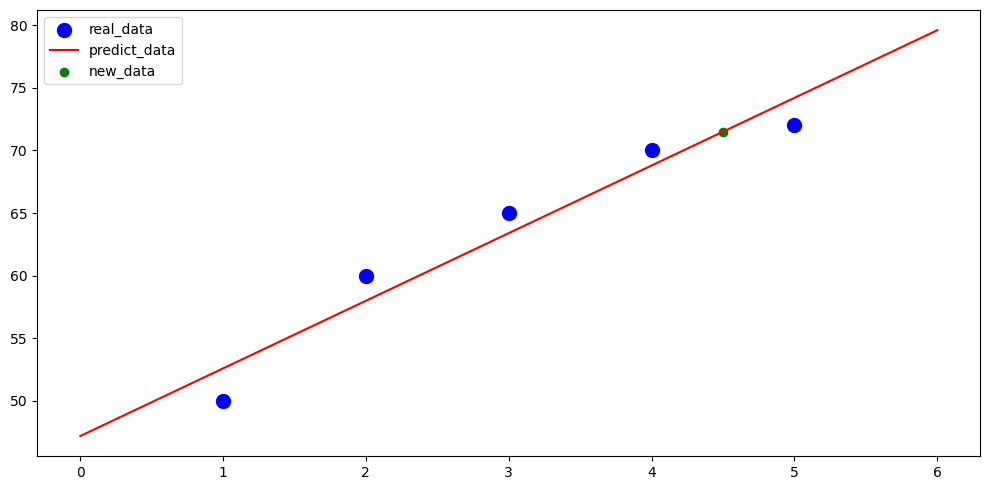

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(x,y,color='blue',s=100, label='real_data')
# 머신러닝이 예측한 예측 값
x_line = np.linspace(0,6,100).reshape(-1,1)
y_line = model.predict(x_line)
ax.plot(x_line,y_line,color='red',label='predict_data')
# 새로운 예측 값
new_x = np.array([[4.5]])
new_y = model.predict(new_x)
ax.scatter(new_x,new_y,color='green',label='new_data')

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [16]:
# 정규화 : 각 원소를 평균으로 뺀 값을 표준편차로 나눔

data = np.array([10,20,30])
data.mean(), data.std()

standard_data = (data - data.mean()) / data.std()
standard_data.mean(), round(standard_data.std(),1)

(np.float64(0.0), np.float64(1.0))

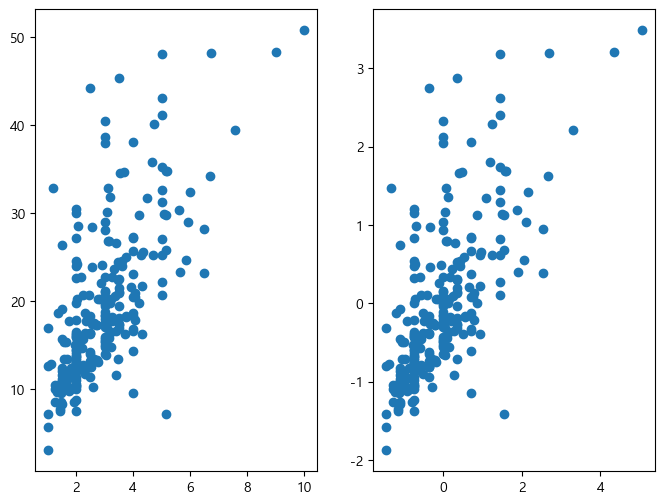

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt 
tips = sns.load_dataset('tips')
fig, axes = plt.subplots(1,2,figsize=(8,6))
axes[0].scatter(tips['tip'],tips['total_bill'])

standard_tip = (tips['tip'] - tips['tip'].mean()) / tips['tip'].std()
standard_total_bill = (tips['total_bill'] - tips['total_bill'].mean()) / tips['total_bill'].std()
axes[1].scatter(standard_tip, standard_total_bill)

# data = tips['total_bill'].values
# fig, axes = plt.subplots(1,2,figsize=(8,6))
# axes[0].hist(data)

# data_mean = data.mean()
# data_std = data.std()
# standard_data = (data - data_mean) / data_std
# axes[1].hist(standard_data)

In [ ]:
# sepal length (cm)	꽃받침 길이
# sepal width (cm)	꽃받침 너비
# petal length (cm)	꽃잎 길이
# petal width (cm)	꽃잎 너비

iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [33]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

df = load_diabetes(as_frame=True).frame
df.head()
x = df[['bmi']]
y = df['target']
print(x.shape,y.shape)

# y = ax + b
# 1. 모델 선택
model = LinearRegression()
# 2. 모델 학습
model.fit(x,y)
# 3. 모델 예측 (추론)
t = model.predict( np.array([[0.061696]]) )
print(t)

(442, 1) (442,)
[210.70984199]


c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
import random
# 순서 섞기
random_index = random.sample(range(442),442)
x2 = x['bmi'][random_index]
y2 = y[random_index]
# 학습 데이터  8 : 테스트 데이터 2 로 분할
split_count = int(len(x['bmi'])*0.8)
x2_train = x2[ :split_count]
y2_train = y2[ :split_count]

x2_test = x2[split_count: ]
y2_test = y2[split_count: ]

# 모델 생성 / 학습
model = LinearRegression()
model.fit(x2_train.to_numpy().reshape(-1,1), y2_train)

#  모델 테스트
predicted = model.predict(x2_test.to_numpy().reshape(-1,1))
predicted[:5], y2_test[:5].to_numpy()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mean_absolute_error(y2_test,predicted), mean_squared_error(y2_test,predicted), r2_score(y2_test,predicted)

(52.432004122794666, 3944.4659871354684, 0.3392187200800032)

In [ ]:
# 데이터 (x,y)
# 데이터를 섞어서 분할 (학습용 / 테스트용)
# 적절한 모델 선택
# 학습 -> 학습용 데이터
# 추론 (예측) -> 테스트용 데이터
# 평가 : 테스트용 데이터의 실제 정답 vs 모델이 테스트용 데이터로 예측한 값의 오차

In [39]:
# 섞는다 train_test_split
from sklearn.model_selection import train_test_split
X = df[['bmi','bp']].to_numpy()
y = df['target'].to_numpy()
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
# 학습 
model.fit(x_train,y_train)
# 예측 
predicted = model.predict(x_test)
# 평가
mean_absolute_error(y2_test,predicted), mean_squared_error(y2_test, predicted), r2_score(y_test,predicted)

(79.20617903796153, 9241.94550649278, 0.2939977566766083)

In [ ]:
# age	    나이 (표준화된 값)
# sex	    성별
# bmi	    체질량지수 (Body Mass Index)
# bp	    평균 혈압
# s1	    혈청 총 콜레스테롤
# s2	    저밀도 지단백 (LDL)
# s3	    고밀도 지단백 (HDL)
# s4	    총 콜레스테롤 / HDL 비율
# s5	    혈청 트리글리세라이드
# s6	    혈당 수준
# target    1년 후 질병 진행 정도
# 모든 칼럼은 평균 0, 표준편차 1로 정규화 되어있음

# 당뇨병 정보
load_diabetes(as_frame=True).frame
df.head(1)

In [41]:
y = np.array([1,2,3,4])
y_hat = np.array([1.2, 1.9, 3.2, 3.7])

# 평균
y_mean = y.mean()
# SS_tot : 데이터 자체의 변동성 / 오차 제곱의 합
SS_tot = sum((y-y_mean)**2)
# SS_res : 모델 오차
SS_res = sum((y-y_hat)**2) 
# R2_score(결정계수) 1 - SS_res / SS_tot
R2_score = 1 - SS_res / SS_tot
y_mean, SS_tot, SS_res, R2_score


(np.float64(2.5),
 np.float64(5.0),
 np.float64(0.17999999999999997),
 np.float64(0.964))